In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

=====  first 5 rows of the dataset =====
   age          workclass  fnlwgt   education  education-num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital-status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital-gain  capital-loss  hours-per-week  native-country  income  
0          2174            

<Figure size 1200x600 with 0 Axes>

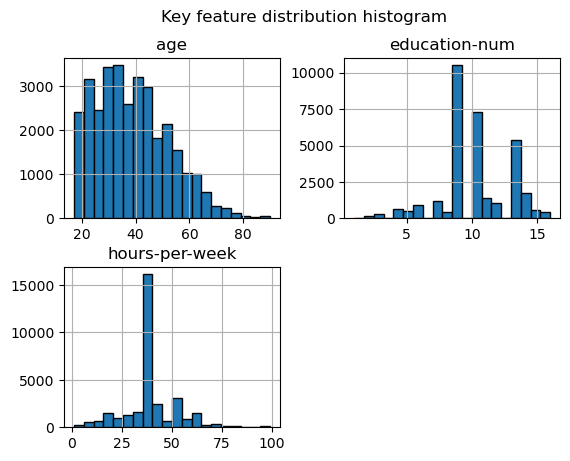

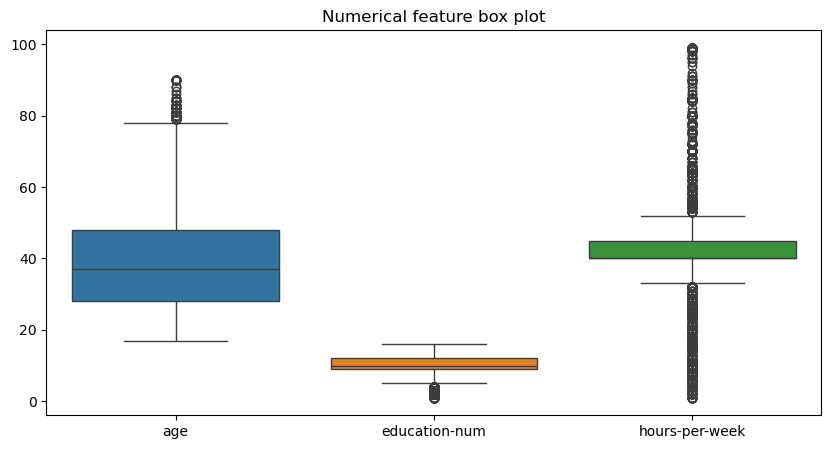

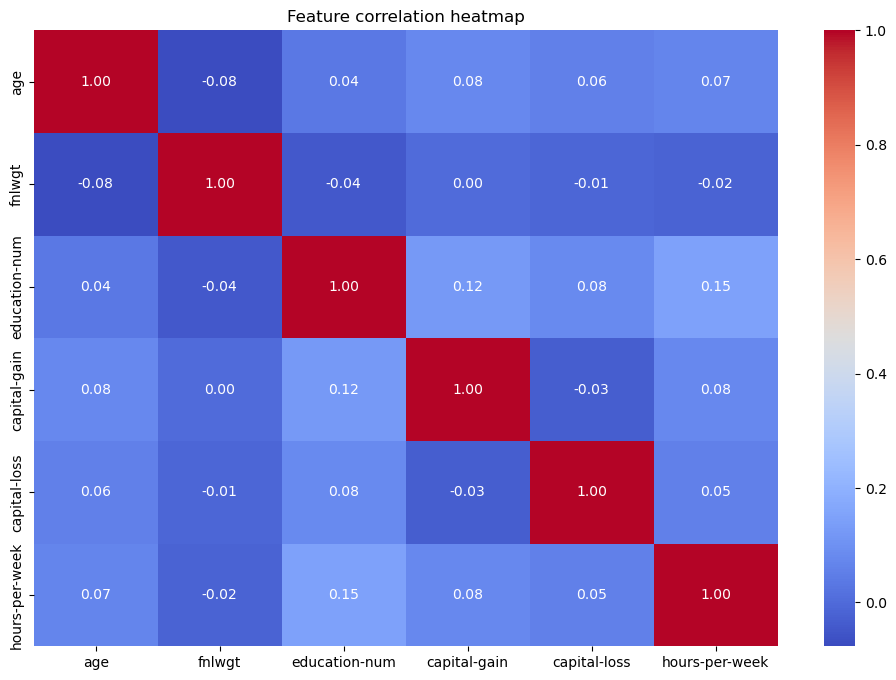

In [15]:
# 1) Data Loading and Exploration:
# Data loading
df = pd.read_csv("adults.csv") 

# Data Exploration:
#  first 5 rows of the dataset
print("=====  first 5 rows of the dataset =====")
print(df.head())

# Explore the dataset using methods like head(), describe(), and info()
print("\n===== Information =====")
print(df.info())

print("\n===== Description =====")
print(df.describe())

# Visualize distributions of key features using histograms
plt.figure(figsize=(12, 6))
df[['age', 'education-num', 'hours-per-week']].hist(bins=20, edgecolor='black')
plt.suptitle('Key feature distribution histogram')
plt.show()

# Visualize distributions of key features using boxplots
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['age', 'education-num', 'hours-per-week']])
plt.title('Numerical feature box plot')
plt.show()

# feature correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature correlation heatmap')
plt.show()


In [19]:
# Check for missing values 
# In the Adult dataset, missing values are often marked as '?'
df.replace('?', np.nan, inplace=True)
print("\nMissing Values Count per Feature:\n", df.isnull().sum())

# Handling missing values by dropping rows
df.dropna(inplace=True)

# Convert the target variable 'income' to numeric (e.g., <=50K=0, >50K=1) 
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])

# Convert categorical features into numeric format using One-Hot Encoding 
df_processed = pd.get_dummies(df, drop_first=True)

# Separate features (X) and target variable (y)
X = df_processed.drop('income', axis=1)
y = df_processed['income']

# Implement feature scaling (essential for KNN performance) 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)


Missing Values Count per Feature:
 age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [21]:
# 3) Model Building:
# Initialize classification models
knn_model = KNeighborsClassifier()
dt_model = DecisionTreeClassifier(random_state=42)

# Train both models on the training data
knn_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)

# Predict labels for the test set
knn_predictions = knn_model.predict(X_test)
dt_predictions = dt_model.predict(X_test)


--- KNN Evaluation ---
Accuracy Score: 0.8224
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.89      4942
           1       0.65      0.57      0.61      1571

    accuracy                           0.82      6513
   macro avg       0.76      0.74      0.75      6513
weighted avg       0.82      0.82      0.82      6513


--- Decision Tree Evaluation ---
Accuracy Score: 0.8177
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4942
           1       0.62      0.64      0.63      1571

    accuracy                           0.82      6513
   macro avg       0.75      0.76      0.75      6513
weighted avg       0.82      0.82      0.82      6513



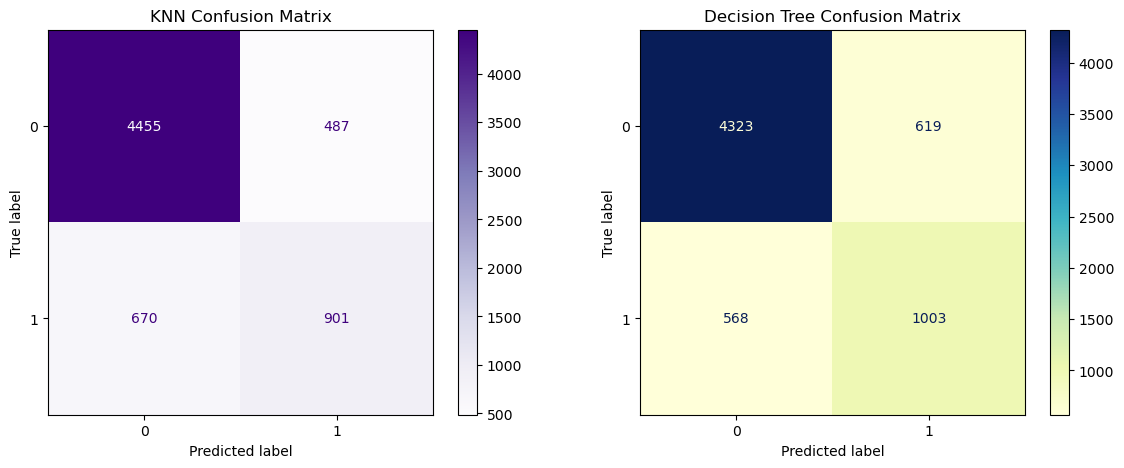

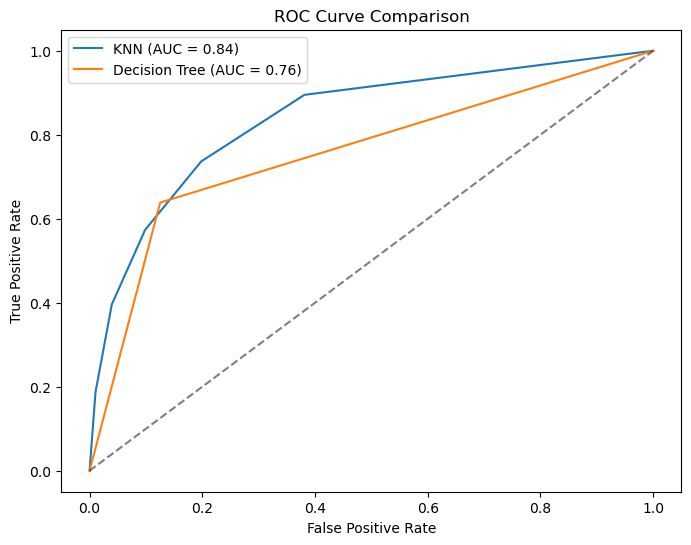

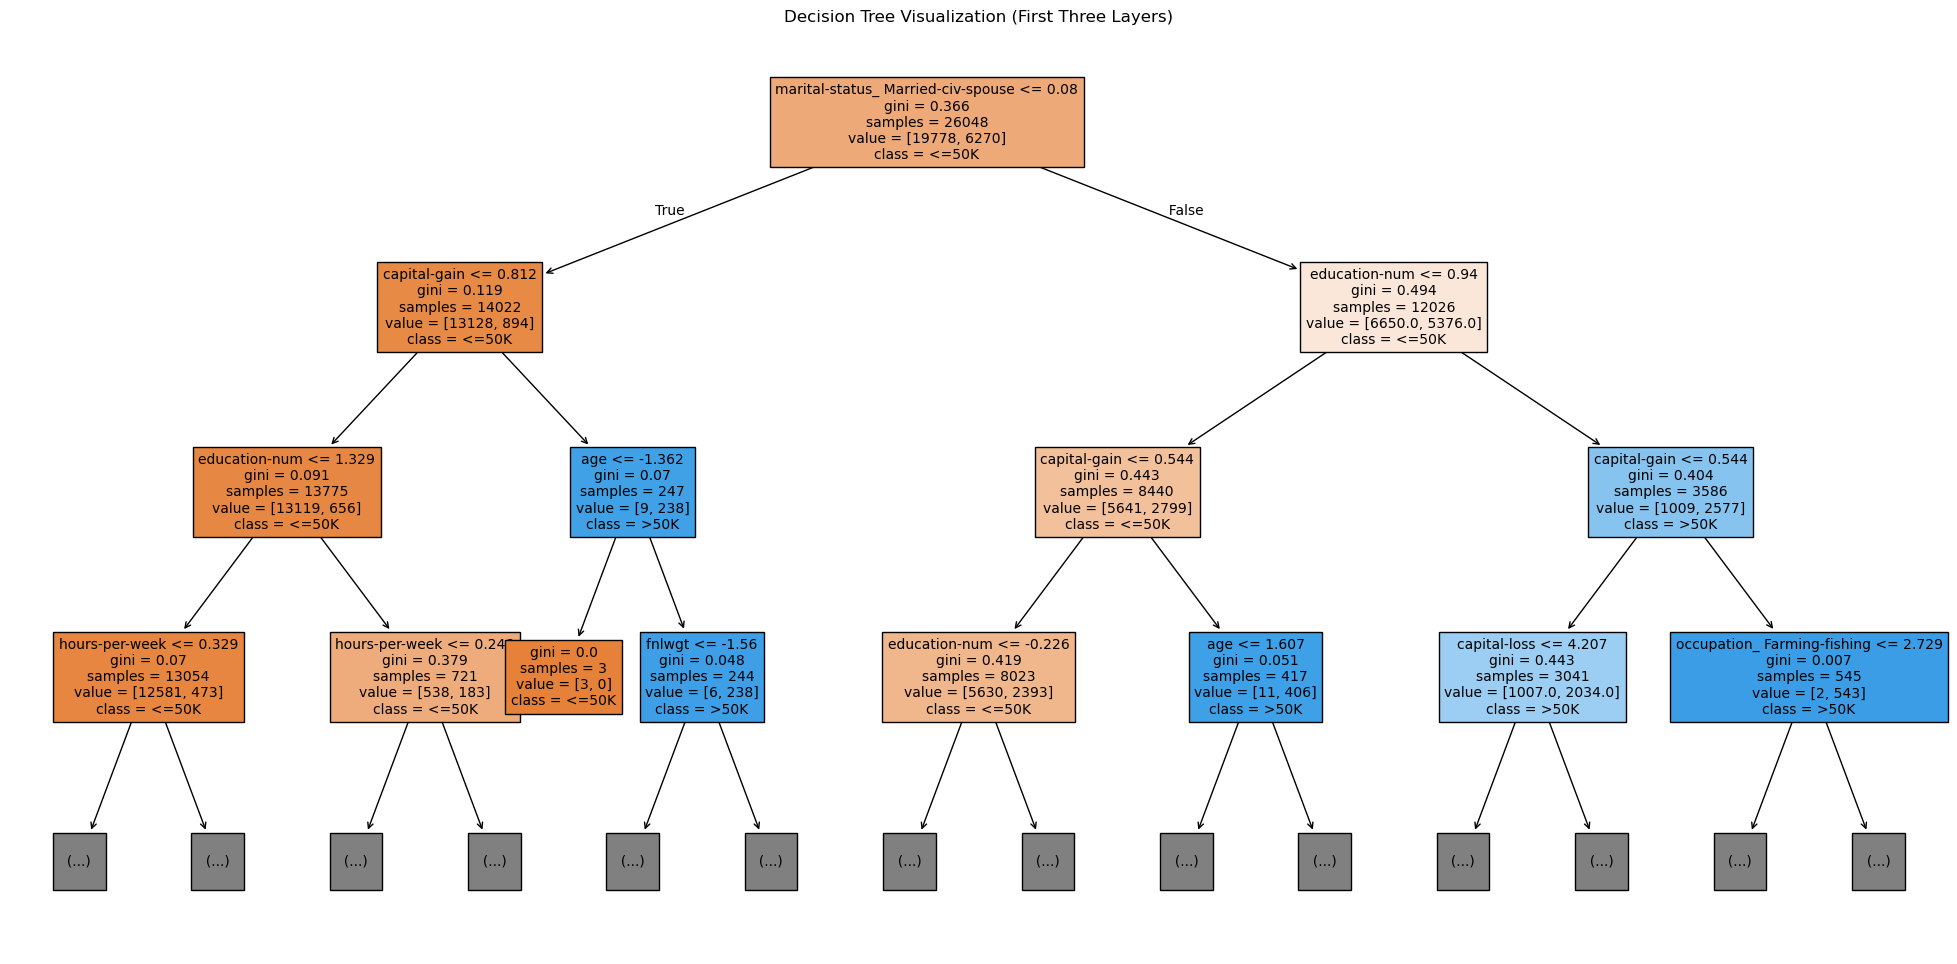

In [23]:
# 4) Model Evaluation:
# Print accuracy_score and classification report for both models
for name, predictions in [("KNN", knn_predictions), ("Decision Tree", dt_predictions)]:
    print(f"\n--- {name} Evaluation ---")
    print(f"Accuracy Score: {accuracy_score(y_test, predictions):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, predictions))

# Visualize confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, knn_predictions, ax=axes[0], cmap='Purples')
axes[0].set_title("KNN Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(y_test, dt_predictions, ax=axes[1], cmap='YlGnBu')
axes[1].set_title("Decision Tree Confusion Matrix")
plt.show()

# Draw ROC curves for both models 
plt.figure(figsize=(8, 6))
for model, label in [(knn_model, "KNN"), (dt_model, "Decision Tree")]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# Visualize the structure of the decision tree (First 3 layers) 
plt.figure(figsize=(25, 12))
plot_tree(dt_model, max_depth=3, feature_names=X.columns, 
          class_names=['<=50K', '>50K'], filled=True, fontsize=10)
plt.title("Decision Tree Visualization (First Three Layers)")
plt.show()

In [25]:
# 5) Hyperparameter Tuning:
# Tuning KNN: Search for the best number of neighbors
knn_param_grid = {'n_neighbors': [3, 5, 7, 11]}
grid_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5)
grid_knn.fit(X_train, y_train)

# Tuning Decision Tree: Search for best depth and split criteria 
dt_param_grid = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5)
grid_dt.fit(X_train, y_train)

# Output best parameters and performance
print(f"\nBest KNN Parameters: {grid_knn.best_params_}")
print(f"Best Decision Tree Parameters: {grid_dt.best_params_}")


Best KNN Parameters: {'n_neighbors': 11}
Best Decision Tree Parameters: {'max_depth': 10, 'min_samples_split': 2}


In [27]:
# 6) Cross Validation:
# Perform 5-fold cross validation 
knn_cv_scores = cross_val_score(grid_knn.best_estimator_, X_scaled, y, cv=5)
dt_cv_scores = cross_val_score(grid_dt.best_estimator_, X_scaled, y, cv=5)

print(f"\nKNN Cross-Validation Accuracies: {knn_cv_scores}")
print(f"KNN Average Accuracy: {knn_cv_scores.mean():.4f}")
print(f"Decision Tree Cross-Validation Accuracies: {dt_cv_scores}")
print(f"Decision Tree Average Accuracy: {dt_cv_scores.mean():.4f}")


KNN Cross-Validation Accuracies: [0.82220175 0.83062039 0.82324939 0.83169533 0.82386364]
KNN Average Accuracy: 0.8263
Decision Tree Cross-Validation Accuracies: [0.85060648 0.85288698 0.85426904 0.86210074 0.85718673]
Decision Tree Average Accuracy: 0.8554



--- Model Performance Comparison Table ---
             Metric       KNN  Decision Tree
0     Test Accuracy  0.822355       0.817749
1  Mean CV Accuracy  0.826326       0.855410
2           ROC-AUC  0.838930       0.756597


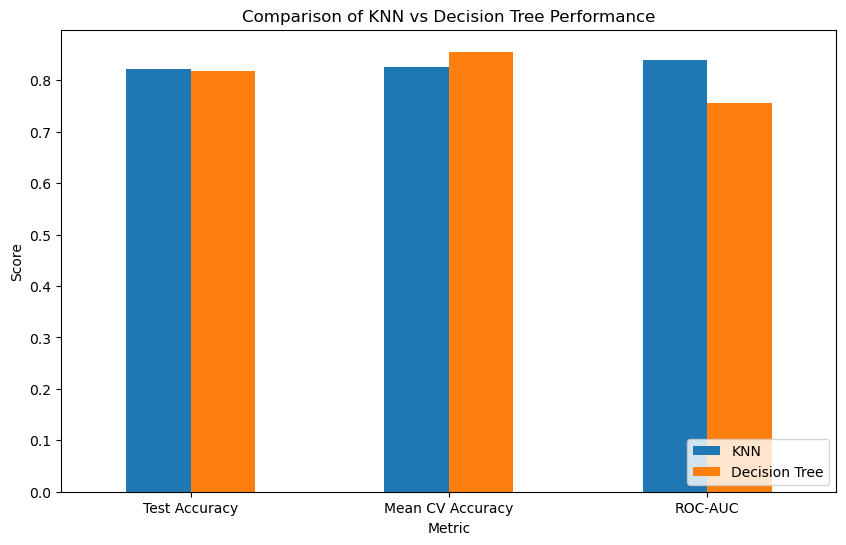

In [31]:
# 7) Performance Comparison:
# Create a comparison table
comparison_metrics = {
    'Metric': ['Test Accuracy', 'Mean CV Accuracy', 'ROC-AUC'],
    'KNN': [
        accuracy_score(y_test, knn_predictions),
        knn_cv_scores.mean(),
        auc(roc_curve(y_test, knn_model.predict_proba(X_test)[:, 1])[0], 
            roc_curve(y_test, knn_model.predict_proba(X_test)[:, 1])[1])
    ],
    'Decision Tree': [
        accuracy_score(y_test, dt_predictions),
        dt_cv_scores.mean(),
        auc(roc_curve(y_test, dt_model.predict_proba(X_test)[:, 1])[0], 
            roc_curve(y_test, dt_model.predict_proba(X_test)[:, 1])[1])
    ]
}

comparison_df = pd.DataFrame(comparison_metrics)
print("\n--- Model Performance Comparison Table ---")
print(comparison_df)

# Final comparison chart
comparison_df.set_index('Metric').plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of KNN vs Decision Tree Performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()